# Fisher classifier

The Fisher classifier use the linear discriminant analysis to classify the object into a class. The main idea of this classifier is to use the LDA to reduce the dimensionality and classify on the reduced feature space. In this notebook we use the Iris dataset to show how it works.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Loading the dataset with pandas
iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


We can easily

In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

x = iris_df[['sepal width (cm)','sepal length (cm)']].values.reshape(-1, 2)

clf = LinearDiscriminantAnalysis()
clf.fit(x,iris_data.target)

print(clf.predict([[5.0, 3.5]]))

[0]


## Fisher's classifier from scratch

We can implement the Fisher's classifier calculating the mean values.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn . datasets import load_iris
from sklearn import preprocessing
iris_data , iris_labels = load_iris(return_X_y = True)
iris_data = np.array(preprocessing.normalize(iris_data))  ### normalize data so that each row is a vector with norm=1

x1 = iris_data [ np.where ( iris_labels == 1) ][: ,[0 ,1]] ## choose class1 and 2 features  
x2 = iris_data [ np.where ( iris_labels == 2) ][: ,[0 ,1]] ## choose class2 and 2 features  
y = iris_labels

mean_x1 , mean_x2 = np.mean( x1 , axis =0) , np.mean( x2 , axis =0) ## mean of features within the classes 
mean = np.mean ( np.append ( x1 , x2 ) )    ## mean of all data 
##Sb = np.sum( ( mean_x1- mean )*( mean_x2 -mean ) )   ## variance of means of classes 
Sw = np.dot(( x1 - mean_x1 ).T , ( x1 - mean_x1 ) ) + np.dot(( x2 - mean_x2 ).T , ( x2 -mean_x2 ) ) ### how data are scatter within the class

w = np.dot( np.linalg.inv( Sw ) , ( mean_x2 - mean_x1 ) )  ## weights

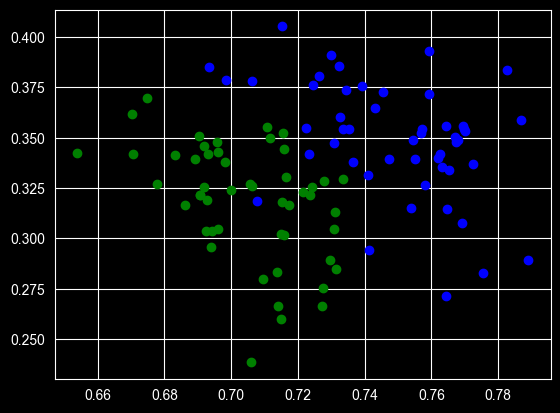

In [5]:
plt.plot ( x1[:,0] , x1[:,1]  , "bo" )
plt.plot ( x2[:,0] , x2[:,1]  , "go" )

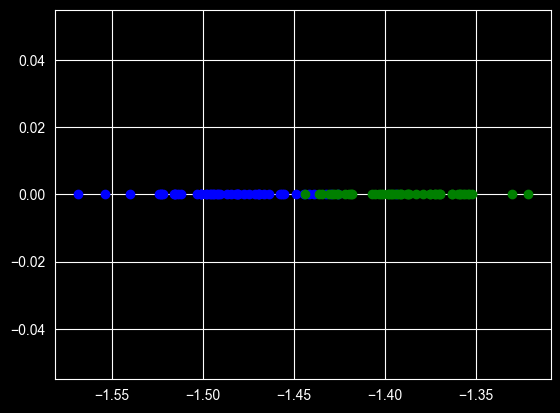

In [6]:
plt.plot ( np.dot( x1 , w ) , [0]* x1.shape[0] , "bo" )
plt.plot ( np.dot( x2 , w ) , [0]* x2.shape[0] , "go" )